Problem Statement: This analysis investigates the public opinion on the Avengers Endgame movie during its trend on twitter as well as its association across different themes and the characters in the movie. 

In [ ]:
# import 
from gettext import install

import pandas as pd
import matplotlib.pyplot as plt
import pip
import seaborn as sns
import re
from collections import Counter
from textblob import TextBlob

In [8]:
df = pd.read_csv('tweets.csv', encoding='latin-1')

# preview 
df.head()

,Unnamed: 0,text,favorited,favoriteCount,replyToSN,created,truncated,replyToSID,id,replyToUID,statusSource,screenName,retweetCount,isRetweet,retweeted,longitude,latitude
0,1,RT @mrvelstan: literally nobody:\r\nme:\r\n\r\...,False,0,NaN,2019-04-23 10:43:30,False,NaN,1120639328034676737,NaN,"<a href=""http://twitter.com/download/android"" ...",DavidAc96,637,True,False,NaN,NaN
1,2,"RT @agntecarter: im emotional, sorry!!\r\n\r\...",False,0,NaN,2019-04-23 10:43:30,False,NaN,1120639325199196160,NaN,"<a href=""http://twitter.com/download/iphone"" r...",NRmalaa,302,True,False,NaN,NaN
2,3,saving these bingo cards for tomorrow \r\n©\r\...,False,0,NaN,2019-04-23 10:43:30,False,NaN,1120639324683292674,NaN,"<a href=""http://twitter.com/download/iphone"" r...",jijitsuu,0,False,False,NaN,NaN
3,4,RT @HelloBoon: Man these #AvengersEndgame ads ...,False,0,NaN,2019-04-23 10:43:29,False,NaN,1120639323328540672,NaN,"<a href=""http://twitter.com/download/iphone"" r...",SahapunB,23781,True,False,NaN,NaN
4,5,"RT @Marvel: We salute you, @ChrisEvans! #Capta...",False,0,NaN,2019-04-23 10:43:29,False,NaN,1120639321571074048,NaN,"<a href=""http://twitter.com/download/iphone"" r...",stella22_97,13067,True,False,NaN,NaN


In [9]:
# total num of rows and columns 
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")

# check datatypes and missing values 
print("Dataset Information:")
df.info()

Dataset Shape: 15000 rows and 17 columns.

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     15000 non-null  int64  
 1   text           15000 non-null  object 
 2   favorited      15000 non-null  bool   
 3   favoriteCount  15000 non-null  int64  
 4   replyToSN      397 non-null    object 
 5   created        15000 non-null  object 
 6   truncated      15000 non-null  bool   
 7   replyToSID     369 non-null    float64
 8   id             15000 non-null  int64  
 9   replyToUID     397 non-null    float64
 10  statusSource   15000 non-null  object 
 11  screenName     15000 non-null  object 
 12  retweetCount   15000 non-null  int64  
 13  isRetweet      15000 non-null  bool   
 14  retweeted      15000 non-null  bool   
 15  longitude      4 non-null      float64
 16  latitude       4 non-null     

In [10]:
# check for missing values 
df.isnull().sum()

# drop rows with missing values 
df = df.dropna(subset=['text'])

# check for total num of rows and columns after dropping missing values 
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")


Dataset Shape: 15000 rows and 17 columns.



In [11]:
print(df.columns)
#df = df.drop(columns=['Unnamed: 0'])

Index(['Unnamed: 0', 'text', 'favorited', 'favoriteCount', 'replyToSN',
       'created', 'truncated', 'replyToSID', 'id', 'replyToUID',
       'statusSource', 'screenName', 'retweetCount', 'isRetweet', 'retweeted',
       'longitude', 'latitude'],
      dtype='object')


In [12]:
# basic descriptive stats 
# highlights followers, friends, and favs (likes)
average_favorited = df['favoriteCount'].mean()
average_retweet = df['retweetCount'].mean()

print(f"The average Twitter user in this dataset has {average_favorited:.2f} favourites.")
print(f"The average number of retweets (likes) associated with these users is {average_retweet:.2f}.")
 
# top 5 most favourited tweets
top_tweets_by_favourited = df[['screenName', 'text', 'favoriteCount']].sort_values(by='favoriteCount', ascending=False).head(5)
top_tweets_by_favourited

The average Twitter user in this dataset has 0.19 favourites.
The average number of retweets (likes) associated with these users is 5912.46.


,screenName,text,favoriteCount
4157,SSMusicTweet,"After #Viswasam, #Petta &amp; #Kanchana3 #Aven...",184
13147,oppomobileindia,"Heroic hand-held power and endurance, our Marv...",183
12371,TicketNew,#CONTEST: Here's a question about someone we a...,161
9876,hmvtweets,WIN an #AvengersEndgame merch bundle! Simply R...,159
7388,CevansOfficial,I just I love this picture! <U+0001F499> #Endg...,135


In [13]:
# top 5 most retweeted tweets 
top_tweets_by_retweet = df[['screenName', 'text', 'retweetCount']].sort_values(by='retweetCount', ascending=False).head(5)
top_tweets_by_retweet

,screenName,text,retweetCount
3487,billsup_,RT @Avengers: Whatever it takes. Watch the bra...,114850
7308,HelenaB94527435,RT @Marvel: Whatever it takes. Watch the brand...,100500
11373,dairlena,RT @Avengers: Here's your first look at the ne...,85686
4048,JuuanKrlos,RT @ChrisEvans: 1 month. #AvengersEndgame http...,66596
13623,VaitheesGVW,"RT @MarvelStudios: Before were done, we stil...",48795


In [14]:
# filter 
all_tweets = " ".join(tweet for tweet in df['text'].astype(str))
all_tweets = all_tweets.lower()

words = re.findall(r'\b[a-z]{4,}\b', all_tweets)

stop_words = ['paytm','marvelstudios','what','endgame', 'movie', 'times','are', 'avengersendgame', 'https', 'these', 'with', 'helloboon', 'everywhere', 'this', 'your', 'that', 'world', 'marvel', 'avengers', 'here']
meaningful_words = [word for word in words if word not in stop_words]

word_counts = Counter(meaningful_words)
top_words = word_counts.most_common(15)

words_to_plot = [item[0] for item in top_words]
counts_to_plot = [item[1] for item in top_words]

print("Word frequencies calculated successfully!")

Word frequencies calculated successfully!


/var/folders/k7/t32643cn28qc5hpk99j57v_c0000gn/T/ipykernel_47152/3976523685.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=words_to_plot, y=counts_to_plot, palette="viridis")


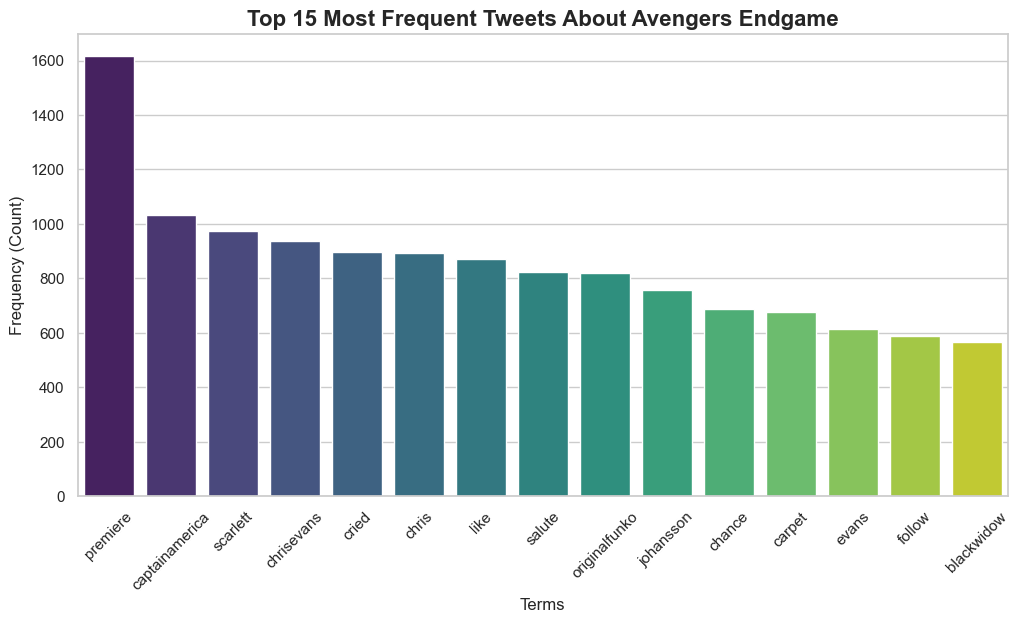

In [15]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.barplot(x=words_to_plot, y=counts_to_plot, palette="viridis")

plt.title('Top 15 Most Frequent Tweets About Avengers Endgame', fontsize=16, fontweight='bold')
plt.xlabel('Terms', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.xticks(rotation=45)

plt.show()

In [16]:
def get_polarity(text):
    # calculates a score from -1.0 to +1.0
    return TextBlob(str(text)).sentiment.polarity

df['polarity_score'] = df['text'].apply(get_polarity)

# display text with mathematical score 
df[['text', 'polarity_score']].head()

,text,polarity_score
0,RT @mrvelstan: literally nobody:\r\nme:\r\n\r\...,0.000000
1,"RT @agntecarter: im emotional, sorry!!\r\n\r\...",-0.390625
2,saving these bingo cards for tomorrow \r\n©\r\...,0.000000
3,RT @HelloBoon: Man these #AvengersEndgame ads ...,0.000000
4,"RT @Marvel: We salute you, @ChrisEvans! #Capta...",0.000000


In [17]:
# categorize the score
def categorize_sentiment(score):
    if score > 0.05:          # positive
        return 'Positive'
    elif score < -0.05:       # negative
        return 'Negative'
    else:                     # neutral
        return 'Neutral'

df['sentiment'] = df['polarity_score'].apply(categorize_sentiment)
df[['screenName', 'text', 'sentiment']].head(10)

,screenName,text,sentiment
0,DavidAc96,RT @mrvelstan: literally nobody:\r\nme:\r\n\r\...,Neutral
1,NRmalaa,"RT @agntecarter: im emotional, sorry!!\r\n\r\...",Negative
2,jijitsuu,saving these bingo cards for tomorrow \r\n©\r\...,Neutral
3,SahapunB,RT @HelloBoon: Man these #AvengersEndgame ads ...,Neutral
4,stella22_97,"RT @Marvel: We salute you, @ChrisEvans! #Capta...",Neutral
5,Legend662,RT @MCU_Direct: The first NON-SPOILER #Avenger...,Positive
6,imjustabandgeek,RT @Renner4Real: Ready to rock ! #excited #...,Positive
7,wtfmy00,RT @Avengers: Were with him til the end of t...,Neutral
8,fIawlesstorm,RT @Variety: #AvengersEndgame first reactions:...,Positive
9,adeyeh,RT @HelloBoon: Man these #AvengersEndgame ads ...,Neutral


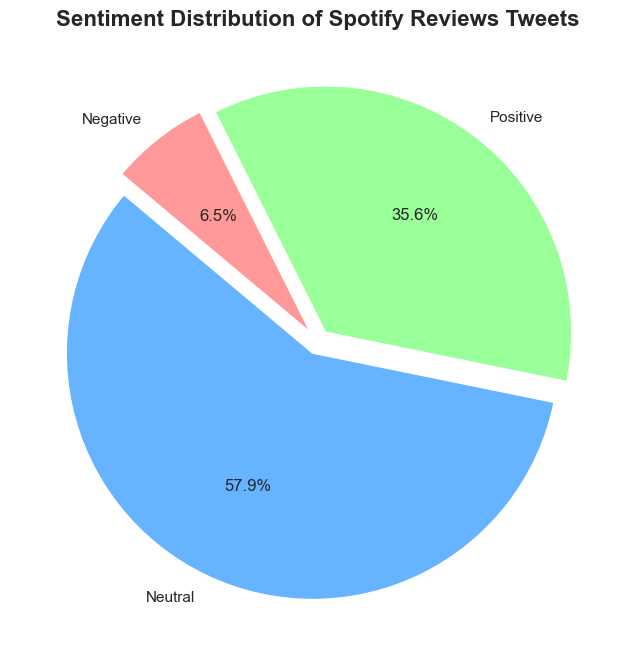


Exact Count per category:
sentiment
Neutral     8686
Positive    5340
Negative     974
Name: count, dtype: int64


In [18]:
# count how many tweets fall into each category
sentiment_counts = df['sentiment'].value_counts()

# pie chart visualization
plt.figure(figsize=(8, 8))
colors = ['#66b3ff', '#99ff99', '#ff9999'] # Blue(Neutral), Green(Positive), Red(Negative)
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
        startangle=140, colors=colors, explode=(0.05, 0.05, 0.05))

plt.title('Sentiment Distribution of Spotify Reviews Tweets', fontsize=16, fontweight='bold')
plt.show()

print("\nExact Count per category:")
print(sentiment_counts)

Importing nltk resources

In [ ]:
import nltk

nltk.download('punkt')      # Rules for tokenization (chopping text)
nltk.download('punkt_tab')  # NEW requirement for tokenization in updated NLTK versions
nltk.download('stopwords')  # List of common, uninformative words
nltk.download('wordnet')    # Massive English dictionary for Lemmatization
nltk.download('omw-1.4')    # Supporting data for WordNet

print("NLTK Resources Downloaded Successfully!")

df_sample = df.sample(n=2000, random_state=42).copy()
print(f"Working with a sample of {len(df_sample)} tweets.")

NLTK Resources Downloaded Successfully!
Working with a sample of 2000 tweets.


[nltk_data] Downloading package punkt to /Users/ad/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/ad/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/ad/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/ad/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/ad/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [26]:
from nltk.tokenize import word_tokenize

def tokenize_and_clean(text):
    # 1. Case Folding: Convert to lowercase
    text = str(text).lower()

    # 2. Remove URLs/Links (Internet noise)
    text = re.sub(r'http\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text, flags=re.MULTILINE)
    text = re.sub(r'#', '', text, flags=re.MULTILINE)

    # 3. Tokenization: Chop into words
    tokens = word_tokenize(text)

    # 4. Punctuation Removal: Keep only tokens that are alphabetical words (e.g., COVID-19 will be removed)
    clean_tokens = [word for word in tokens if word.isalpha()]

    return clean_tokens

df['tokens'] = df['text'].apply(tokenize_and_clean)

# Let's compare the raw text to our new tokens!
df[['text', 'tokens']].head()

,text,tokens
0,RT @mrvelstan: literally nobody:\r\nme:\r\n\r\...,"[rt, literally, nobody, me, avengersendgame]"
1,"RT @agntecarter: im emotional, sorry!!\r\n\r\...","[rt, emotional, sorry, x, blackwidow, captaina..."
2,saving these bingo cards for tomorrow \r\n©\r\...,"[saving, these, bingo, cards, for, tomorrow, a..."
3,RT @HelloBoon: Man these #AvengersEndgame ads ...,"[rt, man, these, avengersendgame, ads, are, ev..."
4,"RT @Marvel: We salute you, @ChrisEvans! #Capta...","[rt, we, salute, you, captainamerica, avengers..."


In [27]:
from nltk.corpus import stopwords

# Load the English stopwords list
stop_words = set(stopwords.words('english'))

# We can also add custom stopwords specific to our dataset if we want
custom_stopwords = ['rt','paytm','marvelstudios','what','endgame', 'movie', 'times','are', 'avengersendgame', 'with', 'helloboon', 'marvel', 'avengers']
stop_words.update(custom_stopwords)

def remove_stopwords(token_list):
    # Keep the word ONLY if it is not in our stop_words list
    filtered_tokens = [word for word in token_list if word not in stop_words]
    return filtered_tokens

# Apply to our tokens
df['filtered_tokens'] = df['tokens'].apply(remove_stopwords)

# Compare the tokens before and after stopword removal
df[['tokens', 'filtered_tokens']].head()

,tokens,filtered_tokens
0,"[rt, literally, nobody, me, avengersendgame]","[literally, nobody]"
1,"[rt, emotional, sorry, x, blackwidow, captaina...","[emotional, sorry, x, blackwidow, captainamerica]"
2,"[saving, these, bingo, cards, for, tomorrow, a...","[saving, bingo, cards, tomorrow]"
3,"[rt, man, these, avengersendgame, ads, are, ev...","[man, ads, everywhere]"
4,"[rt, we, salute, you, captainamerica, avengers...","[salute, captainamerica]"


In [28]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Initialize our two tools
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def apply_stemming(token_list):
    return [stemmer.stem(word) for word in token_list]

def apply_lemmatization(token_list):
    return [lemmatizer.lemmatize(word) for word in token_list]

# Create two new columns to compare the results
df['stemmed_words'] = df['filtered_tokens'].apply(apply_stemming)
df['lemmatized_words'] = df['filtered_tokens'].apply(apply_lemmatization)

print("Stemming and Lemmatization complete!")

df[['filtered_tokens', 'stemmed_words', 'lemmatized_words']].head()

Stemming and Lemmatization complete!


,filtered_tokens,stemmed_words,lemmatized_words
0,"[literally, nobody]","[liter, nobodi]","[literally, nobody]"
1,"[emotional, sorry, x, blackwidow, captainamerica]","[emot, sorri, x, blackwidow, captainamerica]","[emotional, sorry, x, blackwidow, captainamerica]"
2,"[saving, bingo, cards, tomorrow]","[save, bingo, card, tomorrow]","[saving, bingo, card, tomorrow]"
3,"[man, ads, everywhere]","[man, ad, everywher]","[man, ad, everywhere]"
4,"[salute, captainamerica]","[salut, captainamerica]","[salute, captainamerica]"


In [32]:
row_to_inspect = 113 # test around 

print("1. ORIGINAL TEXT:")
print(df['text'].iloc[row_to_inspect])
print("\n2. TOKENIZED & NOISE REMOVED:")
print(df['tokens'].iloc[row_to_inspect])
print("\n3. STOPWORDS REMOVED:")
print(df['filtered_tokens'].iloc[row_to_inspect])
print("\n4. STEMMED (Chopped endings):")
print(df['stemmed_words'].iloc[row_to_inspect])
print("\n5. LEMMATIZED (Dictionary root):")
print(df['lemmatized_words'].iloc[row_to_inspect])

1. ORIGINAL TEXT:
RT @MCU_Direct: Coulson (@clarkgregg) greeted fans during tonight's #AvengersEndgame purple carpet world premiere! https://t.co/slYedwnzeY

2. TOKENIZED & NOISE REMOVED:
['rt', 'coulson', 'greeted', 'fans', 'during', 'tonight', 'avengersendgame', 'purple', 'carpet', 'world', 'premiere']

3. STOPWORDS REMOVED:
['coulson', 'greeted', 'fans', 'tonight', 'purple', 'carpet', 'world', 'premiere']

4. STEMMED (Chopped endings):
['coulson', 'greet', 'fan', 'tonight', 'purpl', 'carpet', 'world', 'premier']

5. LEMMATIZED (Dictionary root):
['coulson', 'greeted', 'fan', 'tonight', 'purple', 'carpet', 'world', 'premiere']
